In [2]:
# # To avoid issues with multiple OpenMP libraries being loaded
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os


#Statistical tests
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Plot
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
directory = '../hpc_result/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [11]:
df.describe()

3

In [12]:
df = df.dropna()

In [13]:
# Define and fit the model
model = smf.mixedlm("psnr_score ~ attack + C(target_class)", data=df, groups=df["dataset_index"]).fit()

# Print the summary
print(model.summary())


c:\Users\rdh\AppData\Local\miniconda3\envs\AdvAttacks\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\rdh\AppData\Local\miniconda3\envs\AdvAttacks\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\rdh\AppData\Local\miniconda3\envs\AdvAttacks\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\rdh\AppData\Local\miniconda3\envs\AdvAttacks\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\rdh\AppData\Local\miniconda3\envs\AdvAttacks\Lib\site-packages\statsmodels\base\mode

              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    psnr_score 
No. Observations:    46484      Method:                REML       
No. Groups:          5444       Scale:                 2.1633     
Min. group size:     2          Log-Likelihood:        -85425.3207
Max. group size:     15         Converged:             No         
Mean group size:     8.5                                          
------------------------------------------------------------------
                      Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept             74.810    0.034 2195.271 0.000 74.743 74.876
attack[T.fgsm]        11.071    0.017  662.206 0.000 11.038 11.103
attack[T.pgd]         16.488    0.017  990.180 0.000 16.455 16.520
C(target_class)[T.1]  -0.073    0.045   -1.612 0.107 -0.162  0.016
C(target_class)[T.2]  -0.094    0.046   -2.061 0.039 -0.184 -0.005
C(target_c

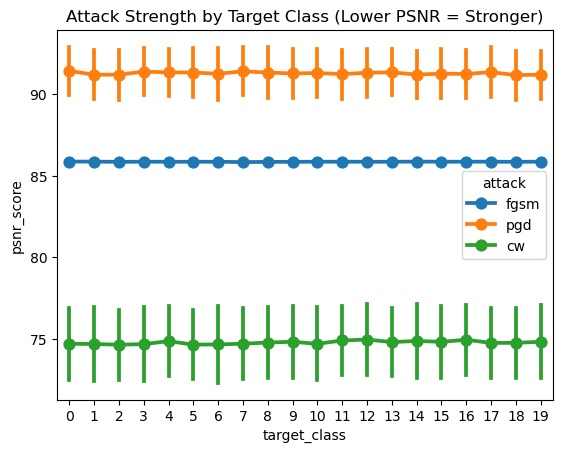

In [14]:
sns.pointplot(data=df, x='target_class', y='psnr_score', hue='attack', errorbar='sd')
plt.title("Attack Strength by Target Class (Lower PSNR = Stronger)")
plt.show()

### KL divergence in probability distribution

In [15]:
df["original_probs"] = df["original_probs"].apply(ast.literal_eval)
df["adversarial_probs"] = df["adversarial_probs"].apply(ast.literal_eval)

C:\Users\rdh\AppData\Local\Temp\ipykernel_5796\4037593332.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["original_probs"] = df["original_probs"].apply(ast.literal_eval)
C:\Users\rdh\AppData\Local\Temp\ipykernel_5796\4037593332.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["adversarial_probs"] = df["adversarial_probs"].apply(ast.literal_eval)


In [16]:
def kl_divergence(p, q):
    # Convert to tensors
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    p = p + epsilon
    q = q + epsilon

    return F.kl_div(q.log(), p, reduction="sum").item()  

In [17]:
df["kl_divergence"] = df.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


C:\Users\rdh\AppData\Local\Temp\ipykernel_5796\3706757358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["kl_divergence"] = df.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


In [18]:
print(df.groupby("attack")["kl_divergence"].mean())

attack
cw      2.082565
fgsm    3.946978
pgd     8.213558
Name: kl_divergence, dtype: float64


In [19]:
print(df[["kl_divergence", "psnr_score"]].corr())

               kl_divergence  psnr_score
kl_divergence       1.000000    0.474389
psnr_score          0.474389    1.000000


In [20]:
model = smf.mixedlm("kl_divergence ~ attack", data=df, groups=df["dataset_index"])
result = model.fit()

print(result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: kl_divergence
No. Observations: 46484   Method:             REML         
No. Groups:       5444    Scale:              13.8129      
Min. group size:  2       Log-Likelihood:     -128492.2028 
Max. group size:  15      Converged:          Yes          
Mean group size:  8.5                                      
-----------------------------------------------------------
                 Coef. Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        2.094    0.033  62.914 0.000  2.028  2.159
attack[T.fgsm]   1.850    0.042  43.790 0.000  1.767  1.932
attack[T.pgd]    6.118    0.042 145.421 0.000  6.036  6.201
Group Var        1.213    0.016                            



# Succesrate

In [21]:
# Create contingency table: rows = attack type, columns = success (True/False)
contingency = pd.crosstab(df['attack'], df['attack_successful'])

print("Contingency Table:\n", contingency)

# Chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("\nChi-squared Test Results:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print("\nExpected Frequencies:\n", pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))


Contingency Table:
 attack_successful  False  True 
attack                         
cw                  8969   6807
fgsm                2507  12734
pgd                    2  15465

Chi-squared Test Results:
Chi2 Statistic: 14397.5584
Degrees of Freedom: 2
P-value: 0.0000e+00

Expected Frequencies:
 attack_successful        False         True 
attack                                      
cw                 3895.467860  11880.532140
fgsm               3763.363695  11477.636305
pgd                3819.168445  11647.831555
